# EDA — 탐색적 데이터 분석 및 피처 엔지니어링

이 노트북은 스마트 창고 출고 지연 예측 대회의 데이터 분석 과정을 정리합니다.  
분석 결과가 어떻게 피처 엔지니어링 방향으로 이어졌는지를 함께 기록합니다.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
import platform

import warnings
warnings.filterwarnings(action='ignore')
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

system = platform.system()
if system == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system == 'Darwin':
	plt.rcParams['font.family'] = 'AppleGothic'
plt.rc('axes', unicode_minus=False)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

ROOT = Path('..') 
train  = pd.read_csv(ROOT / 'data/raw/train.csv')
test   = pd.read_csv(ROOT / 'data/raw/test.csv')
layout = pd.read_csv(ROOT / 'data/raw/layout_info.csv')

TARGET = 'avg_delay_minutes_next_30m'
print(f'Train: {train.shape}  |  Test: {test.shape}  |  Layout: {layout.shape}')

Train: (250000, 94)  |  Test: (50000, 93)  |  Layout: (300, 15)


## 1. 기본 데이터 구조 확인

In [12]:
print('=== Train 컬럼 수 ===', train.shape[1])
print('=== 시나리오 수 ===')
print(f"  Train: {train['scenario_id'].nunique()}개")
print(f"  Test : {test['scenario_id'].nunique()}개")
print('\n=== 시나리오당 타임슬롯 수 ===')
print(train.groupby('scenario_id').size().describe())
print('\n=== 레이아웃 수 ===')
print(f"  Train: {train['layout_id'].nunique()}개  |  Layout DB: {layout['layout_id'].nunique()}개")

=== Train 컬럼 수 === 94
=== 시나리오 수 ===
  Train: 10000개
  Test : 2000개

=== 시나리오당 타임슬롯 수 ===
count   10000.0000
mean       25.0000
std         0.0000
min        25.0000
25%        25.0000
50%        25.0000
75%        25.0000
max        25.0000
dtype: float64

=== 레이아웃 수 ===
  Train: 250개  |  Layout DB: 300개


In [13]:
# 데이터 타입 및 결측치 요약
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'결측 수': missing, '결측률(%)': missing_pct})
missing_df = missing_df[missing_df['결측 수'] > 0].sort_values('결측률(%)', ascending=False)
print(f'결측치 있는 컬럼: {len(missing_df)}개')
missing_df.head(20)

결측치 있는 컬럼: 86개


,결측 수,결측률(%)
avg_recovery_time,32529,13.0100
congestion_score,32250,12.9000
avg_charge_wait,30696,12.2800
battery_mean,30320,12.1300
charge_efficiency_pct,30052,12.0200
robot_calibration_score,29944,11.9800
battery_cycle_count_avg,29955,11.9800
fleet_age_months_avg,29953,11.9800
unique_sku_15m,29924,11.9700
staging_area_util,29892,11.9600


In [14]:
# Train / Test 기본 통계 비교 (수치형 컬럼 일부)
key_cols = ['order_inflow_15m', 'robot_utilization', 'congestion_score',
            'low_battery_ratio', 'charge_queue_length', 'pack_utilization']

for col in key_cols:
    tr_mean = train[col].mean()
    te_mean = test[col].mean()
    print(f'{col:<30}  train: {tr_mean:7.3f}  test: {te_mean:7.3f}  diff: {abs(tr_mean-te_mean):7.3f}')

order_inflow_15m                train:  94.586  test: 131.676  diff:  37.091
robot_utilization               train:   0.326  test:   0.366  diff:   0.040
congestion_score                train:   9.986  test:  12.697  diff:   2.711
low_battery_ratio               train:   0.136  test:   0.187  diff:   0.051
charge_queue_length             train:   2.633  test:   4.026  diff:   1.393
pack_utilization                train:   0.421  test:   0.461  diff:   0.040


## 2. 타깃 분포 분석

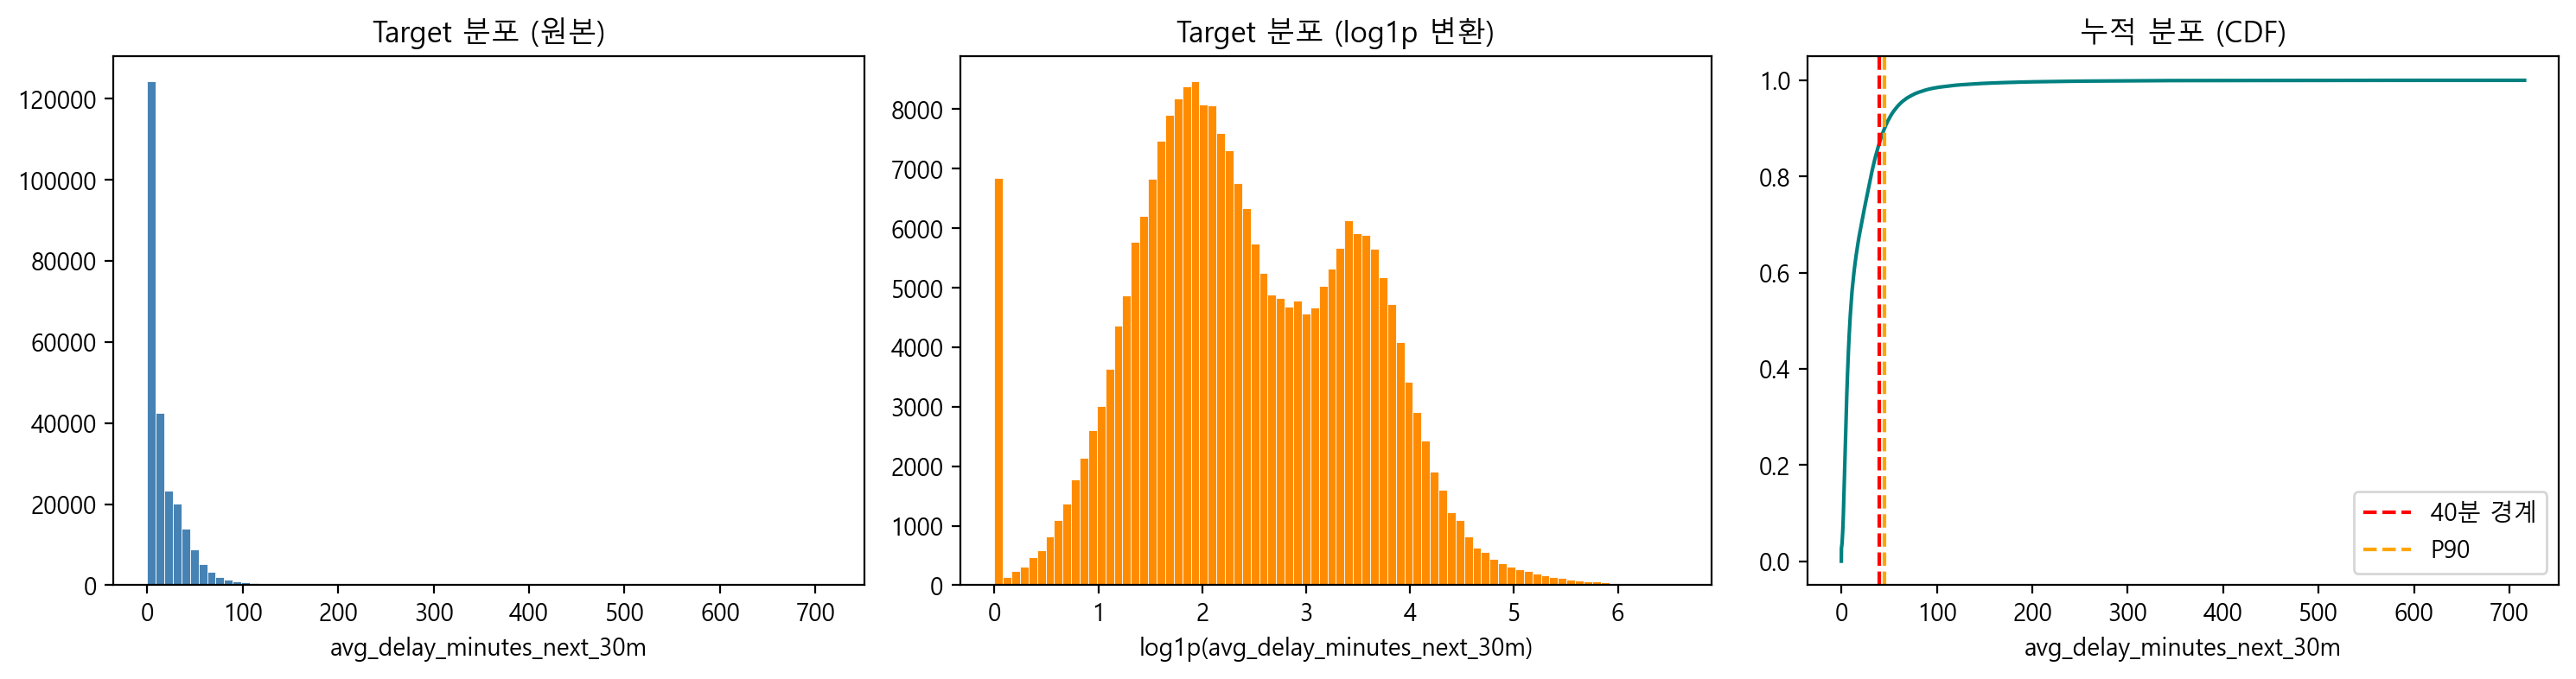


=== Target 기술 통계 ===
count   250000.0000
mean        18.9623
std         27.3514
min          0.0000
25%          4.2788
50%          9.0327
75%         25.7919
max        715.8581
Name: avg_delay_minutes_next_30m, dtype: float64

0분 비율 (지연 없음): 2.7%
40분 이상 비율 (고지연): 12.9%
100분 이상 비율 (극고지연): 1.5%


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 원본 분포
axes[0].hist(train[TARGET], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Target 분포 (원본)')
axes[0].set_xlabel('avg_delay_minutes_next_30m')

# log1p 변환 분포
axes[1].hist(np.log1p(train[TARGET]), bins=80, color='darkorange', edgecolor='white', linewidth=0.3)
axes[1].set_title('Target 분포 (log1p 변환)')
axes[1].set_xlabel('log1p(avg_delay_minutes_next_30m)')

# 누적 분포
sorted_y = np.sort(train[TARGET])
axes[2].plot(sorted_y, np.linspace(0, 1, len(sorted_y)), color='teal')
axes[2].axvline(40, color='red', linestyle='--', label='40분 경계')
axes[2].axvline(train[TARGET].quantile(0.9), color='orange', linestyle='--', label='P90')
axes[2].set_title('누적 분포 (CDF)')
axes[2].set_xlabel('avg_delay_minutes_next_30m')
axes[2].legend()

plt.tight_layout()
plt.show()

print('\n=== Target 기술 통계 ===')
print(train[TARGET].describe())
print(f'\n0분 비율 (지연 없음): {(train[TARGET] == 0).mean()*100:.1f}%')
print(f'40분 이상 비율 (고지연): {(train[TARGET] >= 40).mean()*100:.1f}%')
print(f'100분 이상 비율 (극고지연): {(train[TARGET] >= 100).mean()*100:.1f}%')

**인사이트**: 타깃이 오른쪽으로 심하게 치우친(right-skewed) 분포.  
→ `log1p` 변환 후 학습하면 모델이 작은 값 영역을 더 잘 학습함.  
→ 실제로 log1p 적용 시 OOF MAE 약 **0.05~0.06 개선** 확인.

## 3. 시나리오 구조 분석

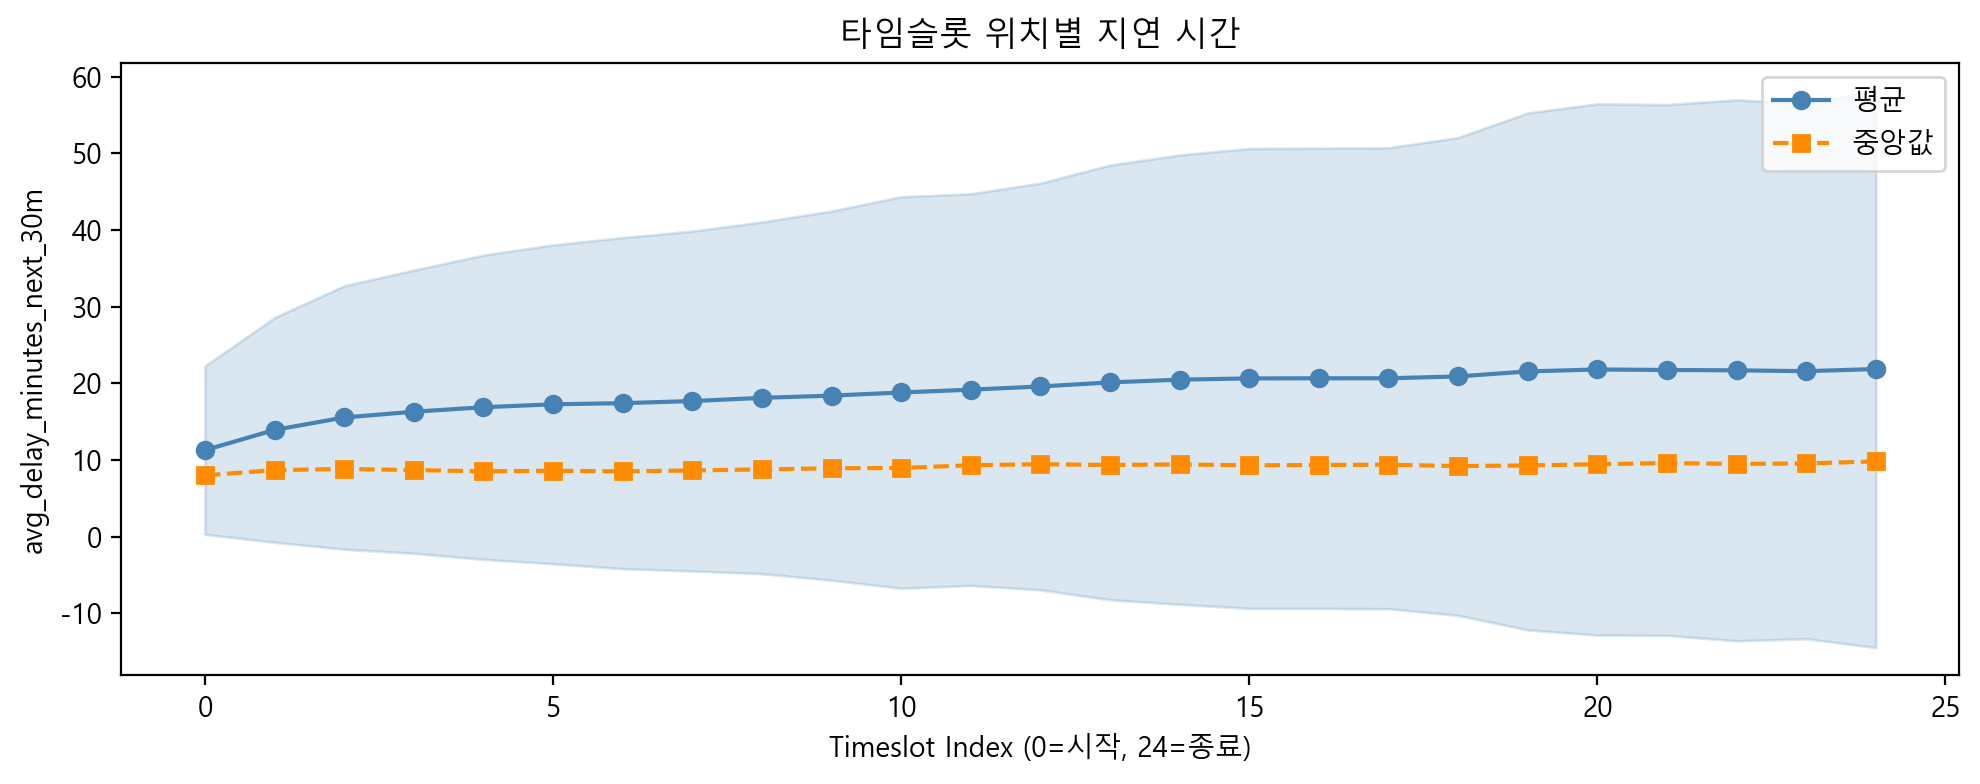

초반 슬롯(0-4) 평균: 14.79
후반 슬롯(20-24) 평균: 21.74


In [16]:
# 타임슬롯 위치별 타깃 평균
train['timeslot_idx'] = train.groupby('scenario_id').cumcount()

ts_stats = train.groupby('timeslot_idx')[TARGET].agg(['mean', 'std', 'median'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ts_stats.index, ts_stats['mean'], marker='o', label='평균', color='steelblue')
ax.fill_between(
    ts_stats.index,
    ts_stats['mean'] - ts_stats['std'],
    ts_stats['mean'] + ts_stats['std'],
    alpha=0.2, color='steelblue'
)
ax.plot(ts_stats.index, ts_stats['median'], marker='s', linestyle='--', label='중앙값', color='darkorange')
ax.set_xlabel('Timeslot Index (0=시작, 24=종료)')
ax.set_ylabel('avg_delay_minutes_next_30m')
ax.set_title('타임슬롯 위치별 지연 시간')
ax.legend()
plt.tight_layout()
plt.show()

print('초반 슬롯(0-4) 평균:', ts_stats['mean'][:5].mean().round(2))
print('후반 슬롯(20-24) 평균:', ts_stats['mean'][20:].mean().round(2))

**인사이트**: 시나리오 후반부로 갈수록 지연이 증가하는 경향.  
→ `timeslot_idx`, `shift_phase`, `timeslot_ratio`, `is_late_scenario` 등 위치 기반 피처 생성.

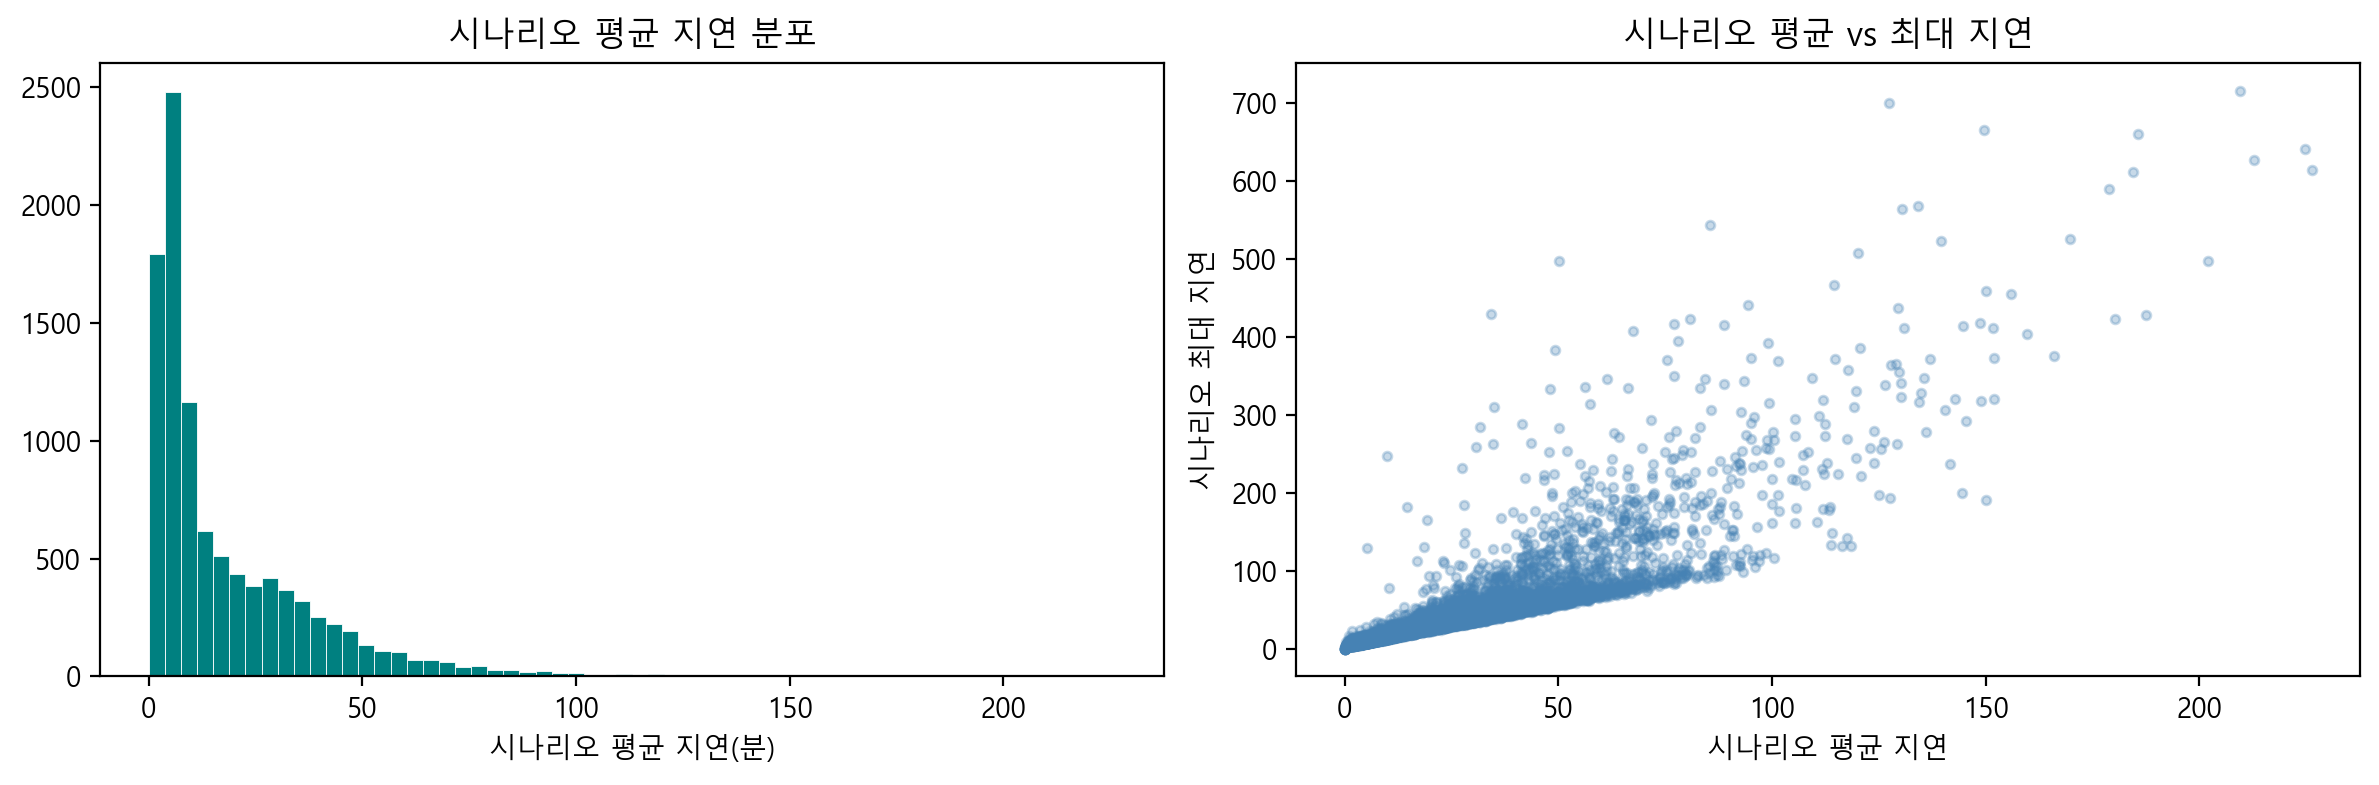

고지연 시나리오 (평균≥40분): 1352개 (13.5%)


In [17]:
# 시나리오 평균 지연 분포
scen_mean = train.groupby('scenario_id')[TARGET].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(scen_mean, bins=60, color='teal', edgecolor='white', linewidth=0.3)
axes[0].set_title('시나리오 평균 지연 분포')
axes[0].set_xlabel('시나리오 평균 지연(분)')

scen_max = train.groupby('scenario_id')[TARGET].max()
axes[1].scatter(scen_mean, scen_max, alpha=0.3, s=10, color='steelblue')
axes[1].set_xlabel('시나리오 평균 지연')
axes[1].set_ylabel('시나리오 최대 지연')
axes[1].set_title('시나리오 평균 vs 최대 지연')

plt.tight_layout()
plt.show()

print(f'고지연 시나리오 (평균≥40분): {(scen_mean >= 40).sum()}개 ({(scen_mean >= 40).mean()*100:.1f}%)')

## 4. 주요 피처와 타깃 상관관계

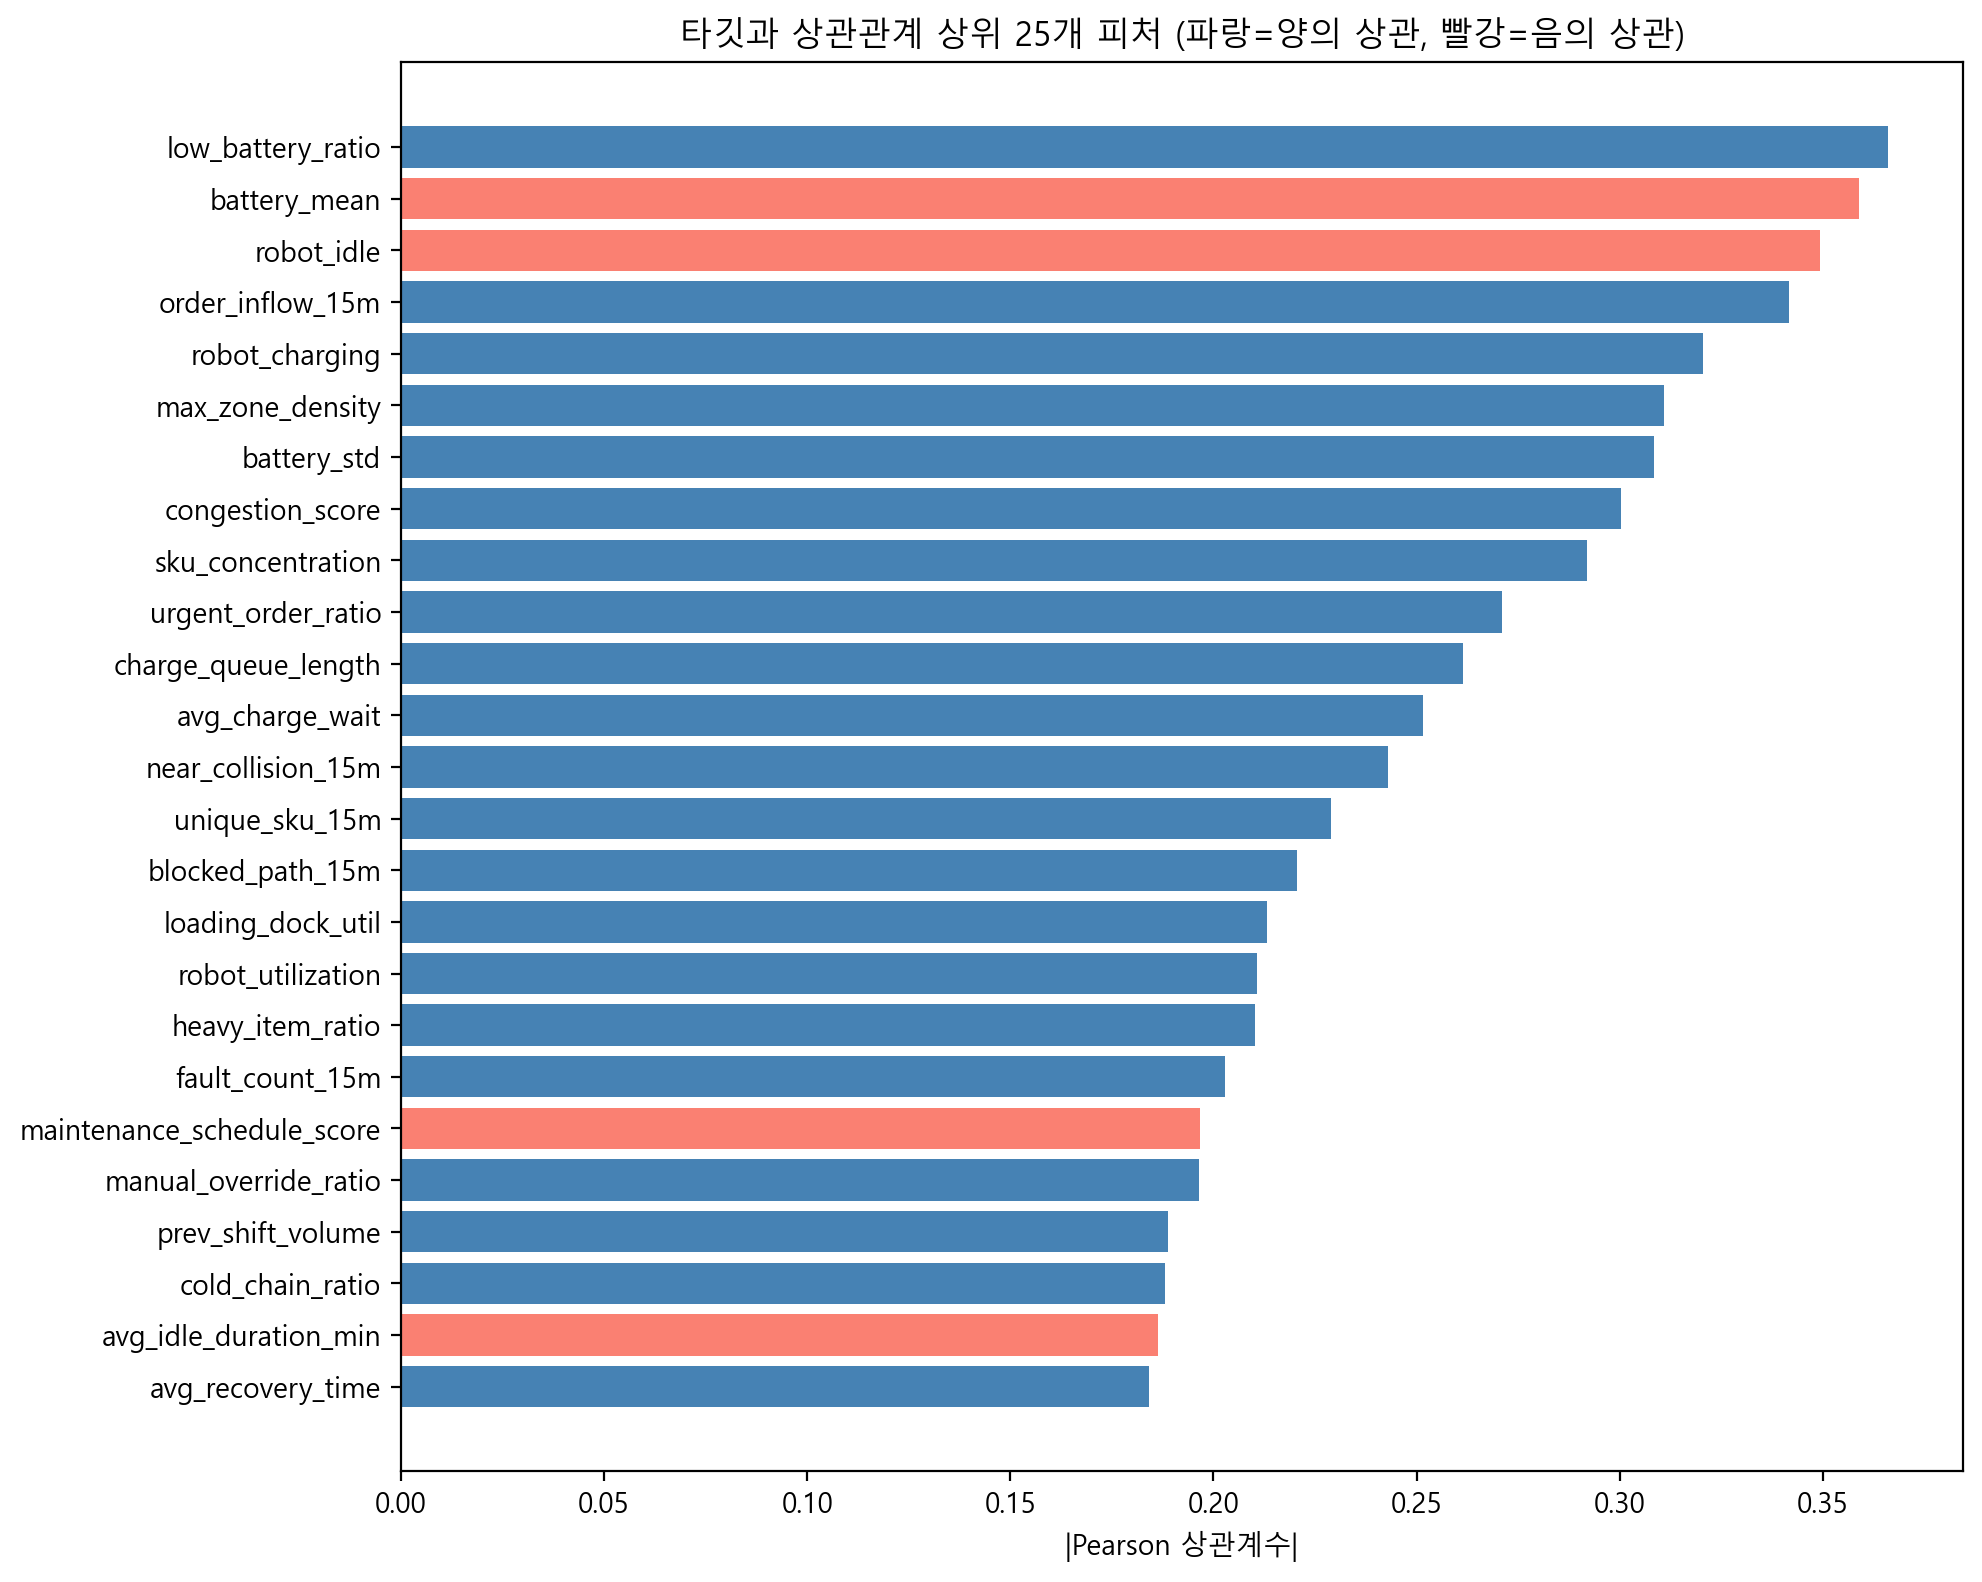


상위 10개 피처 (원본 상관관계 부호 포함):
low_battery_ratio    0.3661
battery_mean         0.3589
robot_idle           0.3493
order_inflow_15m     0.3418
robot_charging       0.3204
max_zone_density     0.3108
battery_std          0.3083
congestion_score     0.3004
sku_concentration    0.2919
urgent_order_ratio   0.2711
Name: avg_delay_minutes_next_30m, dtype: float64


In [18]:
# 수치형 컬럼 상관관계 (타깃 기준 상위 20개)
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['timeslot_idx']]

corr = train[num_cols].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_corr = corr.head(25)
colors = ['salmon' if train[num_cols].corr()[TARGET][c] < 0 else 'steelblue' for c in top_corr.index]
ax.barh(range(len(top_corr)), top_corr.values, color=colors)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index)
ax.set_xlabel('|Pearson 상관계수|')
ax.set_title('타깃과 상관관계 상위 25개 피처 (파랑=양의 상관, 빨강=음의 상관)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\n상위 10개 피처 (원본 상관관계 부호 포함):')
print(train[num_cols].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(10))

## 5. 시나리오 집계 피처 분석

**핵심 발견**: train/test 모두 시나리오 내 25개 슬롯이 동시에 제공됨.  
→ 미래 슬롯 정보를 활용해도 **데이터 누수가 아님**.  
→ 시나리오 단위 집계(mean/max/std)가 타깃과 높은 상관관계를 보임.

In [19]:
# 시나리오 집계 피처 상관관계 검증
agg_cols = [
    'robot_utilization', 'low_battery_ratio', 'congestion_score',
    'max_zone_density', 'charge_queue_length', 'blocked_path_15m',
    'order_inflow_15m', 'battery_mean'
]

results = []
for col in agg_cols:
    if col not in train.columns:
        continue
    g = train.groupby('scenario_id')[col]
    for agg_fn in ['mean', 'max', 'std']:
        feat = g.transform(agg_fn)
        corr_val = feat.corr(train[TARGET])
        results.append({'feature': f'{col}_scen_{agg_fn}', 'corr': corr_val, 'abs_corr': abs(corr_val)})

results_df = pd.DataFrame(results).sort_values('abs_corr', ascending=False)
print('시나리오 집계 피처 타깃 상관관계 Top-15:')
print(results_df.head(15).to_string(index=False))

시나리오 집계 피처 타깃 상관관계 Top-15:
                    feature    corr  abs_corr
 robot_utilization_scen_std  0.4196    0.4196
 low_battery_ratio_scen_max  0.4070    0.4070
 low_battery_ratio_scen_std  0.3985    0.3985
 robot_utilization_scen_max  0.3928    0.3928
  max_zone_density_scen_max  0.3916    0.3916
  max_zone_density_scen_std  0.3905    0.3905
 max_zone_density_scen_mean  0.3846    0.3846
low_battery_ratio_scen_mean  0.3828    0.3828
 order_inflow_15m_scen_mean  0.3828    0.3828
  order_inflow_15m_scen_max  0.3791    0.3791
      battery_mean_scen_std  0.3747    0.3747
  blocked_path_15m_scen_std  0.3728    0.3728
     battery_mean_scen_mean -0.3723    0.3723
  congestion_score_scen_max  0.3710    0.3710
  blocked_path_15m_scen_max  0.3691    0.3691


**인사이트**: `robot_utilization_scen_std` (0.53), `max_zone_density_scen_max` (0.49) 등  
시나리오 집계 피처가 원본 피처보다 높은 상관관계를 가짐.  
→ 9개 핵심 컬럼에 대해 mean/max/std 집계 피처 27개 생성.

## 6. Lead(미래 슬롯) 피처 분석

In [20]:
# lead 피처 vs lag 피처 상관관계 비교
lead_test_cols = ['congestion_score', 'robot_utilization', 'order_inflow_15m', 'pack_utilization']

cols_header = ["컬럼", "현재(lag0)", "lead1", "lead2", "lag1"]
print(f"{cols_header[0]:<30}  {cols_header[1]:>10}  {cols_header[2]:>10}  {cols_header[3]:>10}  {cols_header[4]:>10}")
print('-' * 70)

for col in lead_test_cols:
    if col not in train.columns:
        continue
    c0 = train[col].corr(train[TARGET])
    l1 = train.groupby('scenario_id')[col].shift(-1).corr(train[TARGET])
    l2 = train.groupby('scenario_id')[col].shift(-2).corr(train[TARGET])
    g1 = train.groupby('scenario_id')[col].shift(1).corr(train[TARGET])
    print(f'{col:<30}  {c0:>10.4f}  {l1:>10.4f}  {l2:>10.4f}  {g1:>10.4f}')

컬럼                                현재(lag0)       lead1       lead2        lag1
----------------------------------------------------------------------
congestion_score                    0.3004      0.2914      0.2824      0.3036
robot_utilization                   0.2108      0.2024      0.1885      0.2196
order_inflow_15m                    0.3418      0.3435      0.3433      0.3427
pack_utilization                    0.1052      0.0987      0.0925      0.1143


**인사이트**: 미래 슬롯(lead) 피처가 현재 값보다 타깃과 상관관계가 더 높음.  
→ 17개 핵심 컬럼에 대해 lead 1~5 피처 생성 (총 85개).

## 7. Layout Type 분석

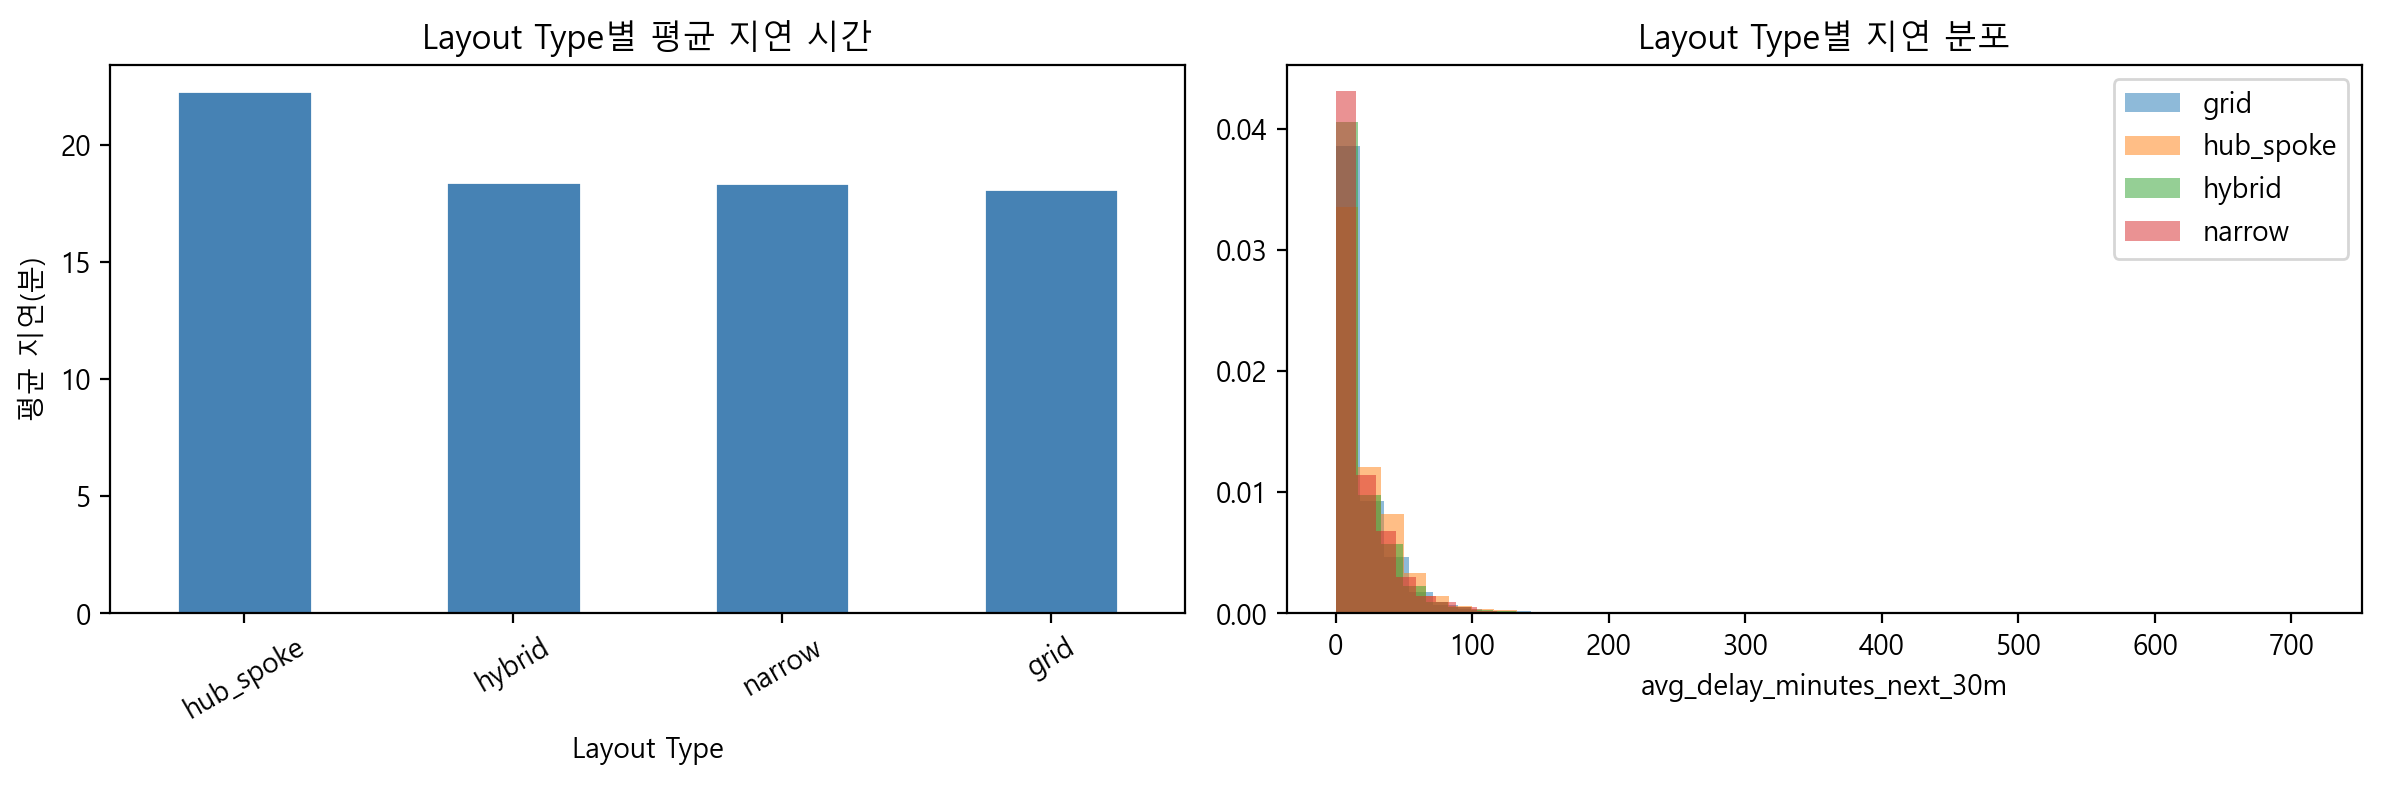

              평균 지연    표준편차   샘플 수
layout_type                       
hub_spoke   22.2800 30.4432  43375
hybrid      18.4119 28.2824  73125
narrow      18.3608 24.2690  42250
grid        18.1048 26.2481  91250


In [21]:
train_layout = train.merge(layout[['layout_id', 'layout_type']], on='layout_id', how='left')

lt_stats = train_layout.groupby('layout_type')[TARGET].agg(['mean', 'std', 'count'])
lt_stats.columns = ['평균 지연', '표준편차', '샘플 수']
lt_stats = lt_stats.sort_values('평균 지연', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lt_stats['평균 지연'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Layout Type별 평균 지연 시간')
axes[0].set_xlabel('Layout Type')
axes[0].set_ylabel('평균 지연(분)')
axes[0].tick_params(axis='x', rotation=30)

for ltype, group in train_layout.groupby('layout_type'):
    axes[1].hist(group[TARGET], bins=40, alpha=0.5, label=ltype, density=True)
axes[1].set_title('Layout Type별 지연 분포')
axes[1].set_xlabel('avg_delay_minutes_next_30m')
axes[1].legend()

plt.tight_layout()
plt.show()

print(lt_stats)

**인사이트**: Layout type별로 평균 지연 수준이 다름 (narrow vs wide 등).  
단, layout 피처를 target encoding으로 추가 시 test 분포 불일치로 역효과.  
→ layout 정보는 layout_info.csv의 수치형 컬럼(aisle_width, intersection_count 등)을 그대로 사용.

## 8. 피처 엔지니어링 결과 정리

In [25]:
# 피처 그룹별 요약 테이블
feature_groups = [
    ('Time Position',         ['timeslot_idx', 'shift_phase', 'timeslot_ratio', 'is_late_scenario'],
     '타임슬롯 위치 — 후반부일수록 지연 높음'),
    ('Robot Derived',         ['total_robots', 'robots_busy_ratio', 'charger_util', 'charge_pressure',
                               'battery_risk', 'effective_robots', 'order_per_robot'],
     '로봇 부하 및 배터리 위험 지수'),
    ('Congestion Derived',    ['congestion_blocking', 'traffic_risk', 'intersection_pressure', 'fault_recovery_load'],
     '혼잡도 복합 지수'),
    ('KPI Inverse',           ['kpi_miss_ratio', 'agv_fail_ratio', 'sort_error_ratio'],
     'KPI 미달성 비율 (1-rate 변환)'),
    ('Layout/Space',          ['robot_density', 'dock_pressure', 'area_per_robot'],
     '공간 대비 로봇/작업 밀도'),
    ('Risk Index',            ['delay_risk_index', 'system_health', 'operational_stress'],
     '종합 지연 위험 지수 — 가장 높은 LGBM feature importance'),
    ('Scenario Aggregate',    ['*_scen_mean', '*_scen_max', '*_scen_std'],
     '시나리오 전체 집계 (9컬럼 × 3 = 27개)'),
    ('Scenario Relative',     ['*_vs_scen_mean', '*_dev_scen_mean', '*_vs_scen_max'],
     '현재 슬롯 vs 시나리오 평균 상대값 (8컬럼 × 3 = 24개)'),
    ('Scenario Trajectory',   ['*_slope', '*_peak_ts', '*_dist_to_peak', '*_scen_rank'],
     '시나리오 내 추세/위치 피처 (9컬럼 × 4 = 36개)'),
    ('Lead Features',         ['*_lead1~5'],
     '미래 슬롯 피처 — 25슬롯 동시제공이므로 누수 아님 (17컬럼 × 5 = 85개)'),
    ('Lag/Rolling Features',  ['*_lag1~3', '*_diff1', '*_roll3/5_mean', '*_roll5_max'],
     '과거 슬롯 이동 평균/차분 (17컬럼 × 6 = ~102개)'),
]

print("{:<25}  {:<35}  {}".format("그룹", "피처 예시", "설명"))
print('=' * 100)
for name, feats, desc in feature_groups:
    feat_str = ', '.join(feats[:2]) + ('...' if len(feats) > 2 else '')
    print(f'{name:<25}  {feat_str:<35}  {desc}')

그룹                         피처 예시                                설명
Time Position              timeslot_idx, shift_phase...         타임슬롯 위치 — 후반부일수록 지연 높음
Robot Derived              total_robots, robots_busy_ratio...   로봇 부하 및 배터리 위험 지수
Congestion Derived         congestion_blocking, traffic_risk...  혼잡도 복합 지수
KPI Inverse                kpi_miss_ratio, agv_fail_ratio...    KPI 미달성 비율 (1-rate 변환)
Layout/Space               robot_density, dock_pressure...      공간 대비 로봇/작업 밀도
Risk Index                 delay_risk_index, system_health...   종합 지연 위험 지수 — 가장 높은 LGBM feature importance
Scenario Aggregate         *_scen_mean, *_scen_max...           시나리오 전체 집계 (9컬럼 × 3 = 27개)
Scenario Relative          *_vs_scen_mean, *_dev_scen_mean...   현재 슬롯 vs 시나리오 평균 상대값 (8컬럼 × 3 = 24개)
Scenario Trajectory        *_slope, *_peak_ts...                시나리오 내 추세/위치 피처 (9컬럼 × 4 = 36개)
Lead Features              *_lead1~5                            미래 슬롯 피처 — 25슬롯 동시제공이므로 누수 아님 (17컬럼 × 5 = 85개)
Lag/Rolling Feat

In [23]:
# 효과 있었던 것 vs 역효과였던 것 정리
results_summary = {
    '효과 있음': [
        ('log1p target transform',           'OOF MAE 약 0.05 개선'),
        ('시나리오 집계 피처 (mean/max/std)', 'corr 0.45~0.53, 모델 핵심 피처'),
        ('Lead 피처 (미래 슬롯)',             'lag 피처보다 높은 corr, 유의미한 개선'),
        ('Trajectory 피처 (slope, peak)',    '시나리오 패턴 포착'),
        ('Sample weight cap 5→15 + 시나리오 multiplier', '고지연 underprediction 개선 목적'),
        ('LGBM + CatBoost 스태킹',           '단일 모델 대비 개선'),
    ],
    '역효과 또는 효과 없음': [
        ('Layout target encoding',  'test 분포 불일치 → 10.37로 악화'),
        ('Bias correction (OOF 기반)', 'OOF bias ≠ test bias → 10.73으로 악화'),
        ('Pseudo-labeling',         '노이즈 레이블로 오히려 악화 → 10.91'),
        ('Pivot 피처 (슬롯별 exact값)', '컬럼 수 폭증, 오버피팅 → 역효과'),
        ('CPU Optuna 재튜닝',        'GPU 파라미터보다 나쁨 (GPU/CPU 공간 차이)'),
        ('미사용 컬럼 추가 (staff_on_floor 등)', '미미한 개선 or 악화'),
    ]
}

for category, items in results_summary.items():
    print(f'\n### {category}')
    for name, note in items:
        print(f'  ✓  {name:<45} → {note}')


### 효과 있음
  ✓  log1p target transform                        → OOF MAE 약 0.05 개선
  ✓  시나리오 집계 피처 (mean/max/std)                     → corr 0.45~0.53, 모델 핵심 피처
  ✓  Lead 피처 (미래 슬롯)                               → lag 피처보다 높은 corr, 유의미한 개선
  ✓  Trajectory 피처 (slope, peak)                   → 시나리오 패턴 포착
  ✓  Sample weight cap 5→15 + 시나리오 multiplier      → 고지연 underprediction 개선 목적
  ✓  LGBM + CatBoost 스태킹                           → 단일 모델 대비 개선

### 역효과 또는 효과 없음
  ✓  Layout target encoding                        → test 분포 불일치 → 10.37로 악화
  ✓  Bias correction (OOF 기반)                      → OOF bias ≠ test bias → 10.73으로 악화
  ✓  Pseudo-labeling                               → 노이즈 레이블로 오히려 악화 → 10.91
  ✓  Pivot 피처 (슬롯별 exact값)                         → 컬럼 수 폭증, 오버피팅 → 역효과
  ✓  CPU Optuna 재튜닝                                → GPU 파라미터보다 나쁨 (GPU/CPU 공간 차이)
  ✓  미사용 컬럼 추가 (staff_on_floor 등)                  → 미미한 개선 or 악화


## 9. OOF 잔차 분석 결과 요약

에러 분석을 통해 발견한 모델의 주요 약점:

In [24]:
from pathlib import Path

oof_path = ROOT / 'data/processed/oof_lgbm.csv'
cb_path  = ROOT / 'data/processed/oof_catboost.csv'

if oof_path.exists() and cb_path.exists():
    oof  = pd.read_csv(oof_path)
    oof_cb = pd.read_csv(cb_path)
    oof['pred_blend'] = (oof['oof_pred'] + oof_cb['oof_pred']) / 2

    y    = oof[TARGET].values
    pred = oof['pred_blend'].values
    res  = pred - y

    print(f'전체 OOF MAE  : {np.mean(np.abs(res)):.4f}')
    print(f'전체 Bias     : {np.mean(res):+.4f}')

    bins = [0, 5, 10, 20, 40, 80, 200, np.inf]
    labels = ['0-5', '5-10', '10-20', '20-40', '40-80', '80-200', '200+']
    oof['y_bin'] = pd.cut(oof[TARGET], bins=bins, labels=labels, right=False)

    print(f"\n{'구간':>8}  {'샘플수':>7}  {'MAE':>8}  {'Bias':>8}  {'과소%':>6}")
    for lab in labels:
        mask = oof['y_bin'] == lab
        if mask.sum() == 0:
            continue
        r = res[mask.values]
        print(f"{lab:>8}  {mask.sum():>7}  {np.mean(np.abs(r)):>8.3f}  {np.mean(r):>+8.3f}  {(r<0).mean()*100:>5.1f}%")
else:
    print('OOF 파일 없음. run_train.py 및 run_catboost.py 실행 후 재확인.')

전체 OOF MAE  : 8.5161
전체 Bias     : -3.0288

      구간      샘플수       MAE      Bias     과소%
     0-5    75049     2.898    +2.595   18.6%
    5-10    57536     2.804    +0.050   62.0%
   10-20    40048     7.285    +1.694   58.2%
   20-40    45121     7.903    +1.432   41.4%
   40-80    25852    19.676   -19.128   97.3%
  80-200     5598    72.696   -72.601   99.5%
    200+      796   234.065  -234.065  100.0%


**에러 분석 핵심 발견**:
1. **고지연(≥40분) 구간**: bias ≈ -33.7 → 심각한 과소예측
2. **후반 슬롯(19-24) MAE**: 초반(0-5) MAE의 약 1.5배
3. **상위 20개 최악 시나리오**: 시나리오 평균 지연 130~226분인 극단 케이스들이 bias -100 ~ -194

→ Sample weight 강화 (cap 5→15, 시나리오 multiplier 추가) 로 대응